# AMP Testing
Approximate Message Passing experiments (random matrix theory).

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from scipy.stats import norm


AMP method comes from statistical physics and goes back to mean field theory to describe spin glasses. In 2003 it was used to decode mobile phone signals, and brough into statistics in 2009 for compressed senssing named "AMP" and show state evolution predicts its accuracy. Now used to calculate limits on what can be learned from a data set.

We observe

$$
A = \frac{\lambda}{n}\, v v^{\top} + W \in \mathbb{R}^{n \times n},
$$

where

- $v \in \{-1, +1\}^n$ is the unknown signal, with $v_i \overset{\text{iid}}{\sim} \mathrm{Unif}\{-1, +1\}$, so $\|v\|^2 = n$
- $W$ is symmetric Gaussian noise, independent of $v$, with $W_{ij} \sim N(0, 1/n)$ for $i < j$ and $W_{ii} \sim N(0, 2/n)$
- $\lambda > 0$ is the signal strength, fixed as $n \to \infty$

**Goal:** estimate $v$ from $A$.

**Performance measure:** the squared overlap between an estimate $\hat v$ and the truth,

$$
\frac{\langle \hat v, v \rangle^2}{\|\hat v\|^2 \, \|v\|^2} \in [0, 1].
$$

So we assume our true value V, has finite entries and further finite variance

## Step 1: Generate the model and check the noise spectrum - Wigner's semicircle law


Before estimating anything, check that $W$ is scaled correctly. With entries of variance $1/n$,
the eigenvalues of $W$ should fill the semicircle law on $[-2, 2]$:

$$
\rho(x) = \frac{1}{2\pi}\sqrt{4 - x^2}, \qquad |x| \le 2.
$$

Adding the spike should leave this bulk unchanged. When $\lambda > 1$, one eigenvalue should
separate from the bulk and sit near $\lambda + 1/\lambda$.

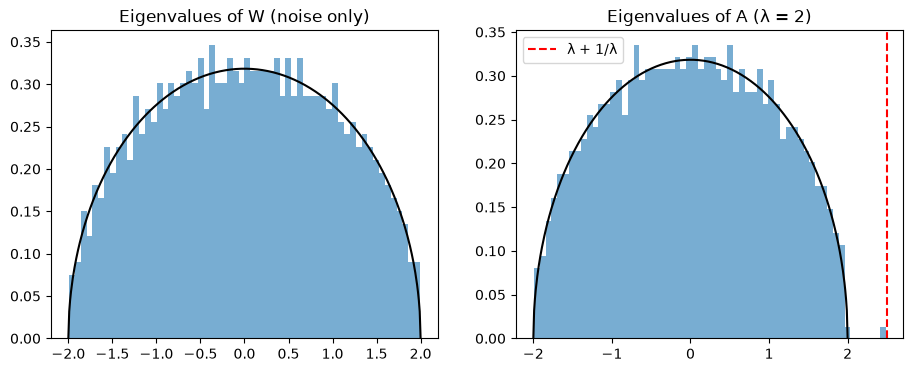

top eigenvalue of A: 2.483435883929448  theory: 2.5


In [3]:
n = 1000
rng = np.random.default_rng(0)
def sample_model(lam,n,rng):
    V = rng.choice([-1.0,1.0], n)
    G = rng.normal(size=(n,n))
    # We are calculating a symetric matrix
    # Must scale it as each diagonal entry is the sum of 2 independet N(0,1) 
    # Now as values are in [-2,2] its we must sqrt it to get back to normal values.
    # As we know that scaling a matrix scales its eigenvalues,
    # A larger matrix has larger eigen values as well, if entries stay the same,
    # Seen in symmetric matrix where the sum of eignvalues, is the sum of the sum of squared entries.
    # Simple maths as we have N^2 entries, n eigien values each value roughly root n.
    W = ( G + G.T ) / np.sqrt(2*n)
    A = (lam / n) * np.outer(V,V) + W
    return A,V,W

lam = 2

A,V,W = sample_model(lam,n,rng)

eig_W = np.linalg.eigvalsh(W)
eig_A = np.linalg.eigvalsh(A)

x = np.linspace(-2,2,400)
semicircle = np.sqrt(4-x**2) / (2* np.pi)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(eig_W, bins=60, density=True, alpha=0.6)
ax[0].plot(x, semicircle, "k")
ax[0].set_title("Eigenvalues of W (noise only)")

ax[1].hist(eig_A, bins=60, density=True, alpha=0.6)
ax[1].plot(x, semicircle, "k")
ax[1].axvline(lam + 1 / lam, color="r", ls="--", label="λ + 1/λ")
ax[1].set_title(f"Eigenvalues of A (λ = {lam})")
ax[1].legend()
plt.show()

print("top eigenvalue of A:", eig_A[-1], " theory:", lam + 1 / lam)

The eigenvalues of a large symmetric random matrix W, with entries of variance 1/n will fill [-2,2] with density seen above. And if true noise occurs, then As eigen value will be lambda + 1/lambda

### BBP transition: the top eigenvalue across λ

A single value of λ only shows what happens at that one signal strength. For a strong signal
(λ > 1), one eigenvalue breaks free of the noise and sits at λ + 1/λ. For a weak signal
(λ ≤ 1), the signal is lost in the noise and the top eigenvalue stays at the noise edge, 2.

To see the transition between these two behaviours, we sweep λ and record the top eigenvalue
of $A$ each time. Theory (Baik, Ben Arous and Péché) predicts


## Recovering v from this top eigien vector 

https://www.youtube.com/watch?v=FD4DeN81ODY

Using PCA is useful, this returning the largest eignvector belonging to the largest eigenvalue. This being called the top or leading eigen vector. 

PCAs theory starts at project as xprime being the amount of information of x that is 

### SVD : Prereq

This is Data Reduction:
- Data-Driven generation of fast - forier transform
- "Tailored" to specific problem
- We can use it to solve Ax = b
## Singular Value Decomposition

Stack data samples $x_k \in \mathbb{R}^n$ as columns: $X = [x_1 \; x_2 \; \cdots \; x_m] \in \mathbb{R}^{n \times m}$

$$
X = U \Sigma V^\top
$$

- $U \in \mathbb{R}^{n \times n}$: left singular vectors ("eigenfaces")
- $\Sigma \in \mathbb{R}^{n \times m}$: diagonal singular values, ordered by importance
- $V \in \mathbb{R}^{m \times m}$: right singular vectors ("eigen time series"); rows of $V^\top$ are mixtures of the $u$'s that make the $x$'s

**Properties**

- $U, V$ unitary: $UU^\top = U^\top U = I_{n \times n}$, $\;VV^\top = V^\top V = I_{m \times m}$
- $\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_m \ge 0$
- Guaranteed to exist; unique up to signs of $(u_k, v_k)$ when the $\sigma_k$ are distinct

### PCA, Change in Basis
One of the goals of PCA is to re-express the noisy data set in a way that it will filter out any noise. So find the unit basis vector. 
This is a method to find the most useful 

So in a 3 Dimensional space each PC
PCA is a searching algorithmn, to find the axis which contribute most to direction.


$PC1$: the single direction which the data varies the most \\\
$PC2$: the direction of greatest remaining variation, perpendicular to PC1
and so on. \\\
$PC3$: What is left

So the Covariance matrix encodes the shape of the data cloude. This allows you to figure out which direction and tells how the data is spread.

The eigenvectors of sigma are the axes of the elipsoid:

A score is a data point's coordinate on a principal component axis.

What is a candidate unit vector:
This is something that is going to be tried out, unit vector


Step 1: Pick any candidate unit vector w (||w|| = 1). Project each centred
data point ( This is data point with the average subtracted off. How much points sits from mean) 
This is in order to centre all the data to the origin


x onto w, giving its score wᵀx. Then take the variance of these
scores across all data points: Var(wᵀx) = wᵀΣw.


So we must find Var(W.tX) =  wᵀΣw subjected wᵀw = 1 

Where we then we take the Lagrangian, differentiate wrt. w and set to 0

2Σw − 2λw = 0 ⟹ Σw = λw which is the same as the eigen value equation so any optimal w must be eigne vector of sigma.

Substitute back in: the variance along w is

wᵀΣw = wᵀ(λw) = λ(wᵀw) = λ

So best w (most variance) is largest eigen value. -> PC1
The second best w is perpendicular to PC1 and is the eigenvector with second largest eignvalue PC2 etc etc etc


Optimisation for PC2 

maximise wᵀΣw
subject to wᵀw = 1 (unit length)
and wᵀw₁ = 0 (perpendicular to PC1)

to  where X is a data measure spot.



So talking about SVD:
The main difference between PCA and SVD is that 
PCA is a statistical question : which direction captures the most variance of my data?

SVD is that "write any matrix as rotation x strech x rotation.
This is a linear algebra decomposition, where it works on any matrix.
Strech x rotation. When you apply to centred data its output answers the same question as PCA

### SVD

Data Reduction
Data-Driven Generalisation of FTT

Solve Ax = b for non square A reegression

### SVD : Prereq

This is Data Reduction:
- Data-Driven generation of fast - forier transform
- "Tailored" to specific problem
- We can use it to solve Ax = b
## Singular Value Decomposition

Stack data samples $x_k \in \mathbb{R}^n$ as columns: $X = [x_1 \; x_2 \; \cdots \; x_m] \in \mathbb{R}^{n \times m}$

$$
X = U \Sigma V^\top
$$

- $U \in \mathbb{R}^{n \times n}$: left singular vectors ("eigenfaces")
- $\Sigma \in \mathbb{R}^{n \times m}$: diagonal singular values, ordered by importance
- $V \in \mathbb{R}^{m \times m}$: right singular vectors ("eigen time series"); rows of $V^\top$ are mixtures of the $u$'s that make the $x$'s

**Properties**

- $U, V$ unitary: $UU^\top = U^\top U = I_{n \times n}$, $\;VV^\top = V^\top V = I_{m \times m}$
- $\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_m \ge 0$
- Guaranteed to exist; unique up to signs of $(u_k, v_k)$ when the $\sigma_k$ are distinct



Our eigen faces are in order the most important to least important

U,V Unitary 

U * U.T , U.T * U = I

As our sigma are diagonal, and sigma is decreasing in size then after a certain point we can ignore and chop them off and approximate matrix x from the first dominant values.

So U (n x n) 
Our left singular vector u1,u2,... are our eigenfaces but built from 


Our Diagonal tells us how important each pattern is 

Finally our V value is the right singular vectors
So how much each pattern goes into each snapshot. So this is why we call it an eigen time series.

### Singular Value Decomposition (SVD)

Let $\mathbf{x}_k \in \mathbb{R}^n$ be snapshots, with $n \gg m$, stacked as columns:

$$
\mathbf{X} =
\begin{bmatrix}
| & | & & | \\
\mathbf{x}_1 & \mathbf{x}_2 & \cdots & \mathbf{x}_m \\
| & | & & |
\end{bmatrix}
= \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\top}
$$

$$
\mathbf{X} = \sum_{k=1}^{m} \sigma_k \mathbf{u}_k \mathbf{v}_k^{\top}
= \sigma_1 \mathbf{u}_1 \mathbf{v}_1^{\top} + \sigma_2 \mathbf{u}_2 \mathbf{v}_2^{\top} + \cdots + \sigma_m \mathbf{u}_m \mathbf{v}_m^{\top}
$$

Each term $\sigma_k \mathbf{u}_k \mathbf{v}_k^{\top}$ has **rank one**: every column is a multiple of $\mathbf{u}_k$. For example,

$$
\begin{pmatrix} 1 \\ 2 \end{pmatrix}
\begin{pmatrix} 3 & 4 & 5 \end{pmatrix}
=
\begin{pmatrix} 3 & 4 & 5 \\ 6 & 8 & 10 \end{pmatrix}
$$

**Economy SVD:** columns $\mathbf{u}_{m+1}, \dots, \mathbf{u}_n$ multiply the zero block of $\boldsymbol{\Sigma}$, so we drop them:

$$
\mathbf{X} = \hat{\mathbf{U}} \hat{\boldsymbol{\Sigma}} \mathbf{V}^{\top}, \qquad \hat{\mathbf{U}} \in \mathbb{R}^{n \times m}, \quad \hat{\boldsymbol{\Sigma}} \in \mathbb{R}^{m \times m}
$$

Truncating after $r$ terms gives the best rank $r$ approximation:
$\mathbf{X}_r = \sum_{k=1}^{r} \sigma_k \mathbf{u}_k \mathbf{v}_k^{\top}$


**Eckart–Young theorem:** $\mathbf{X}_r$ is the *closest* rank $r$ matrix to $\mathbf{X}$:

$$
\mathbf{X}_r = \underset{\operatorname{rank}(\mathbf{A}) \le r}{\arg\min} \, \|\mathbf{X} - \mathbf{A}\|
$$

The error depends only on the discarded singular values:

$$
\|\mathbf{X} - \mathbf{X}_r\|_F = \sqrt{\sigma_{r+1}^2 + \cdots + \sigma_m^2},
\qquad
\|\mathbf{X} - \mathbf{X}_r\|_2 = \sigma_{r+1}
$$

### SVD and the correlation matrices

The correlation matrix $\mathbf{X}^\top\mathbf{X} \in \mathbb{R}^{m \times m}$ contains the inner products of every pair of snapshots:

$$
\mathbf{X}^\top\mathbf{X} =
\begin{bmatrix}
\mathbf{x}_1^\top\mathbf{x}_1 & \mathbf{x}_1^\top\mathbf{x}_2 & \cdots & \mathbf{x}_1^\top\mathbf{x}_m \\
\mathbf{x}_2^\top\mathbf{x}_1 & \mathbf{x}_2^\top\mathbf{x}_2 & \cdots & \mathbf{x}_2^\top\mathbf{x}_m \\
\vdots & \vdots & \ddots & \vdots \\
\mathbf{x}_m^\top\mathbf{x}_1 & \mathbf{x}_m^\top\mathbf{x}_2 & \cdots & \mathbf{x}_m^\top\mathbf{x}_m
\end{bmatrix},
\qquad
\mathbf{x}_i^\top\mathbf{x}_j = \langle \mathbf{x}_i, \mathbf{x}_j \rangle
$$

If $\mathbf{X} = \hat{\mathbf{U}}\hat{\boldsymbol{\Sigma}}\mathbf{V}^\top$, then $\mathbf{X}^\top = \mathbf{V}\hat{\boldsymbol{\Sigma}}\hat{\mathbf{U}}^\top$, so

$$
\mathbf{X}^\top\mathbf{X}
= \mathbf{V}\hat{\boldsymbol{\Sigma}}\underbrace{\hat{\mathbf{U}}^\top\hat{\mathbf{U}}}_{\mathbf{I}}\hat{\boldsymbol{\Sigma}}\mathbf{V}^\top
= \mathbf{V}\hat{\boldsymbol{\Sigma}}^2\mathbf{V}^\top
\quad \Longrightarrow \quad
\mathbf{X}^\top\mathbf{X}\,\mathbf{V} = \mathbf{V}\hat{\boldsymbol{\Sigma}}^2
$$

$$
\mathbf{X}\mathbf{X}^\top
= \hat{\mathbf{U}}\hat{\boldsymbol{\Sigma}}\underbrace{\mathbf{V}^\top\mathbf{V}}_{\mathbf{I}}\hat{\boldsymbol{\Sigma}}\hat{\mathbf{U}}^\top
= \hat{\mathbf{U}}\hat{\boldsymbol{\Sigma}}^2\hat{\mathbf{U}}^\top
\quad \Longrightarrow \quad
\mathbf{X}\mathbf{X}^\top\hat{\mathbf{U}} = \hat{\mathbf{U}}\hat{\boldsymbol{\Sigma}}^2
$$

- Columns of $\mathbf{V}$ are the **eigenvectors** of $\mathbf{X}^\top\mathbf{X}$
- Columns of $\hat{\mathbf{U}}$ are the **eigenvectors** of $\mathbf{X}\mathbf{X}^\top$
- The **eigenvalues** of both are $\sigma_k^2$



### Linking back to our original questions

In [ ]:
mu, u = eigsh(A, k=1, which="LA")
mu, u = mu[0], u[:, 0]              # unpack: plain number, flat vector
lam_hat = (mu + np.sqrt(mu**2 - 4)) / 2 if mu > 2 else 0.0
print(lam_hat)
v_hat = np.sign(u)
acc = np.mean(v_hat == V)
acc = max(acc, 1 - acc)             # score V and -V equally
print("original V: ", V[:15].astype(int))
print("recovered:  ", v_hat[:15].astype(int))
print(f"entries recovered: {acc:.1%}")




1.977831688200391
original V:  [ 1  1  1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1]
recovered:   [-1 -1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1 -1]
entries recovered: 96.2%


### AMP method

So with A = (lambda / n) * V * V.T + W
$$
x_i \approx \underbrace{\lambda q}_{\text{signal}}\, V_i + \underbrace{\sqrt{q}}_{\text{noise}}\, G_i, \qquad G_i \sim N(0,1)
$$

## Approximate Message Passing (AMP)

**Model.** We observe the spiked Wigner matrix
$$
A = \frac{\lambda}{n} V V^\top + W, \qquad V \in \{\pm 1\}^n, \quad W_{ij} = W_{ji} \sim N\!\left(0, \tfrac{1}{n}\right),
$$
and aim to recover $V$ from $A$.

**Initialisation (spectral).** Let $\mu$ and $u$ be the top eigenvalue and eigenvector of $A$. Then
$$
\hat\lambda = \frac{\mu + \sqrt{\mu^2 - 4}}{2}, \qquad \hat\rho = \sqrt{1 - \frac{1}{\hat\lambda^2}}, \qquad
m^0 = \tanh\!\left(\frac{\hat\rho\,\sqrt{n}\,u}{1 - \hat\rho^2}\right), \quad m^{-1} = 0.
$$

**Iteration.** For $t = 0, 1, 2, \dots$
$$
\begin{aligned}
b_t &= \hat\lambda \cdot \frac{1}{n}\sum_{i=1}^n \left(1 - (m_i^t)^2\right) && \text{(Onsager correction)} \\
x^{t+1} &= A\, m^t - b_t\, m^{t-1} && \text{(look at the data)} \\
m^{t+1} &= \tanh\!\left(\hat\lambda\, x^{t+1}\right) && \text{(denoise with the prior)}
\end{aligned}
$$
The final estimate is $\hat V = \operatorname{sign}(m^T)$.

**Decoupling.** Because of the Onsager term, each entry behaves like a scalar Gaussian channel:
$$
x_i^{t} \approx \underbrace{\lambda q_t}_{\text{signal}}\, V_i + \underbrace{\sqrt{q_t}}_{\text{noise}}\, G_i, \qquad G_i \sim N(0,1).
$$

**Optimal denoiser.** For $V_i \in \{\pm 1\}$ observed through this channel, the posterior mean is
$$
\mathbb{E}\left[V_i \mid x_i\right] = \tanh\!\left(\frac{\lambda q_t}{q_t}\, x_i\right) = \tanh(\lambda x_i).
$$

**Overlap.** The quality of the current estimate is measured by
$$
q_t = \frac{1}{n}\sum_{i=1}^n V_i\, m_i^t \;=\; \frac{1}{n}\sum_{i=1}^n (m_i^t)^2 \quad \text{(Nishimori identity)}.
$$

**State evolution.** The overlap evolves according to the scalar recursion
$$
q_{t+1} = \mathbb{E}_{G \sim N(0,1)}\left[\tanh\!\left(\lambda^2 q_t + \lambda \sqrt{q_t}\, G\right)\right], \qquad q_0 = 1 - \frac{1}{\lambda^2},
$$
converging to the fixed point
$$
q^\ast = \mathbb{E}\left[\tanh\!\left(\lambda^2 q^\ast + \lambda \sqrt{q^\ast}\, G\right)\right].
$$

**Accuracy.** The fraction of correctly recovered signs is
$$
\text{acc}_{\text{AMP}} = \Phi\!\left(\lambda \sqrt{q^\ast}\right), \qquad \text{compared with} \qquad
\text{acc}_{\text{spectral}} = \Phi\!\left(\frac{\rho}{\sqrt{1 - \rho^2}}\right) = \Phi\!\left(\lambda\sqrt{q_0}\right).
$$
For $\lambda = 2$: $q^\ast \approx 0.917$, giving $\text{acc}_{\text{AMP}} \approx 97.2\%$ against $\text{acc}_{\text{spectral}} \approx 95.8\%$.

Spectral Initalisation function works simply,
Every AMP needs to start
1) Find top eigenvalue + Vector,
2) Check that spikes exist
3) estimate signal strength $\hat\lambda$ and overlap $\hat\rho$
4) Turn eigenvector into a soft guess for $m_0$

In [44]:
def spectral_init(A):
    mu, u = eigsh(A,k = 1, which = "LA")
    mu , u = mu[0], u.reshape(-1)

    n = len(u)
    #Checking spike does exist
    if mu <= 2:
        raise ValueError(f"mu = {mu:.3f} <= 2: no spike detected")

    lambda_hat = (mu + np.sqrt(mu**2 - 4)) / 2
            

    rho_hat = np.sqrt(1 - 1/ lambda_hat**2)

    m_0 = np.tanh((rho_hat * np.sqrt(n) * u)/ (1 - (rho_hat)**2))
    
    return lambda_hat, rho_hat, m_0

lambda_hat, rho_hat, m_0 = spectral_init(A)

**Iteration.** For $t = 0, 1, 2, \dots$
$$
\begin{aligned}
b_t &= \hat\lambda \cdot \frac{1}{n}\sum_{i=1}^n \left(1 - (m_i^t)^2\right) && \text{(Onsager correction)} \\
x^{t+1} &= A\, m^t - b_t\, m^{t-1} && \text{(look at the data)} \\
m^{t+1} &= \tanh\!\left(\hat\lambda\, x^{t+1}\right) && \text{(denoise with the prior)}
\end{aligned}
$$
The final estimate is $\hat V = \operatorname{sign}(m^T)$.

In [46]:
def iteration_step(lambda_hat, m_prev, m_curr, A):
    b_t = lambda_hat * np.mean(1 - m_curr**2)      # Onsager correction
    x_next = A @ m_curr - b_t * m_prev             # look at the data
    m_next = np.tanh(lambda_hat * x_next)          # denoise with the prior
    return m_next

def run_amp(A, T=50):
    lambda_hat, rho_hat, m_curr = spectral_init(A)
    m_prev = np.zeros_like(m_curr)           
    for t in range(T):
        m_next = iteration_step(lambda_hat, m_prev, m_curr, A)
        m_prev, m_curr = m_curr, m_next
    return np.sign(m_curr)
V_hat = run_amp(A)

print(V_hat)

[-1. -1. -1.  1. -1.  1.  1.  1.  1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1.  1. -1. -1.  1.  1. -1. -1.  1. -1. -1. -1.  1.  1. -1.  1. -1.
  1.  1.  1.  1.  1.  1.  1.  1.  1. -1. -1.  1.  1. -1. -1.  1.  1. -1.
 -1. -1.  1. -1. -1. -1. -1. -1. -1.  1. -1.  1. -1. -1. -1. -1.  1.  1.
  1.  1. -1. -1.  1. -1. -1.  1. -1. -1.  1.  1. -1. -1. -1.  1. -1.  1.
  1. -1.  1.  1. -1. -1.  1.  1.  1.  1.  1. -1.  1.  1. -1. -1.  1.  1.
 -1.  1. -1.  1. -1.  1. -1. -1. -1.  1. -1.  1. -1.  1. -1.  1. -1.  1.
 -1. -1. -1.  1. -1. -1. -1.  1. -1. -1.  1.  1. -1.  1. -1. -1. -1. -1.
  1.  1.  1. -1.  1.  1.  1.  1. -1. -1.  1. -1. -1. -1.  1.  1. -1.  1.
  1.  1.  1. -1.  1. -1.  1.  1.  1. -1. -1. -1. -1. -1.  1.  1.  1. -1.
 -1. -1. -1. -1. -1.  1.  1. -1.  1. -1. -1. -1.  1.  1. -1. -1.  1. -1.
  1. -1.  1.  1.  1.  1. -1. -1.  1. -1. -1.  1.  1. -1. -1.  1.  1. -1.
 -1.  1. -1.  1.  1. -1. -1. -1. -1. -1.  1.  1.  1. -1.  1. -1. -1. -1.
  1.  1.  1. -1. -1.  1. -1.  1.  1.  1. -1. -1.  1

Pros and cons of using Spectral VS AMP

Spectral Pros:
Simple: one eigenvector computation, no iterations.
Robust: Works on any signal shape and tolerates oderate departures 
well understood

cons
suboptimal, only finds direction


AMP

Pros:
Bayyes optimal accuracy: Works better by using tanh denoiser
Soft Estimates, for each mi in (-1,1) acts as a confidence interval
Precise theory: Nimimore identy lets you estimate accuracy without truth
Better with recursion

Cheap per step

Cons:
Model dependent: This is derived only for IID Gaussian noise. If noise is correlated or heavy tailed AMP will behave poorly. Spectral degrade gracefully.
Needs good inputs
Finite n deviations. small n less precise

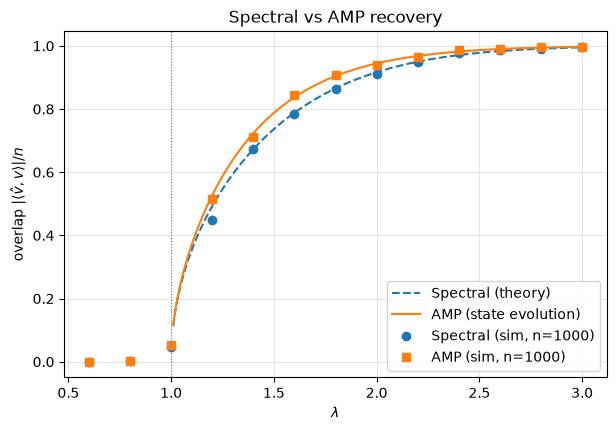

In [52]:

def overlap(V_hat, V):
    return abs(V_hat @ V) / len(V)

def se_fixed_point(lam, T=100, n_mc=200_000, seed=0):
    G = np.random.default_rng(seed).standard_normal(n_mc)
    q = 1 - 1 / lam**2
    for _ in range(T):
        q = np.mean(np.tanh(lam**2 * q + lam * np.sqrt(q) * G))
    return q

trials = 5
lams = np.linspace(0.6, 3.0, 13)
rng = np.random.default_rng(1)
spec_ov, amp_ov = [], []
for lam in lams:
    s, a = [], []
    for _ in range(trials):
        A_l, V_l, _ = sample_model(lam, n, rng)
        try:
            _, _, m0_l = spectral_init(A_l)
            s.append(overlap(np.sign(m0_l), V_l))
            a.append(overlap(run_amp(A_l), V_l))
        except ValueError:
            s.append(0.0); a.append(0.0)
    spec_ov.append(np.mean(s)); amp_ov.append(np.mean(a))

lam_grid = np.linspace(1.01, 3.0, 200)
spec_th = 2 * norm.cdf(np.sqrt(lam_grid**2 - 1)) - 1
amp_th = 2 * norm.cdf(lam_grid * np.sqrt([se_fixed_point(l) for l in lam_grid])) - 1

plt.figure(figsize=(7, 4.5))
plt.plot(lam_grid, spec_th, "--", color="C0", label="Spectral (theory)")
plt.plot(lam_grid, amp_th, "-", color="C1", label="AMP (state evolution)")
plt.plot(lams, spec_ov, "o", color="C0", label=f"Spectral (sim, n={n})")
plt.plot(lams, amp_ov, "s", color="C1", label=f"AMP (sim, n={n})")
plt.axvline(1, color="grey", lw=0.8, ls=":")
plt.xlabel(r"$\lambda$"); plt.ylabel(r"overlap $|\langle \hat v, v\rangle| / n$")
plt.title("Spectral vs AMP recovery")
plt.legend(); plt.grid(alpha=0.3); plt.show()